

# PROJET DE SIMULATION STOCHASTIQUE
# EVOLUTION D'UNE POPULATION D'ALLELES SELON LE MODELE DE WRIGHT-FISHER SANS MUTATION

Soit $N > 2$ un entier fixé. On modélise l'évolution du nombre d'allèles $A$ (version d'un gène) dans une population de $2N$ gènes (supposée de taille constante au cours du temps) par la chaîne de Markov $(X_k)$ de matrice de transition $Q = (q_{i,j})_{0 \le i,j \le 2N} \in \mathcal{M}_{2N+1}(\mathbb{R})$ définie par, pour tout $0 \le i, j \le 2N$ :

$$q_{i,j} = \binom{2N}{j} \left(\frac{i}{2N}\right)^j \left(1 - \frac{i}{2N}\right)^{2N-j}$$

La loi de $X_{k+1}$ sachant que $X_k = i$ est la loi binomiale $\mathcal{B}\left(2N, \frac{i}{2N}\right)$.

Dans la suite, pour signifier que la chaîne démarre à l'état $i \in [0, 2N]$ (i.e. $X_0 = i$ p.s.) lors des calculs de probabilités et d'espérances, on notera respectivement $\mathbb{P}_i$ et $\mathbb{E}_i$.

In [104]:
import numpy as np
from scipy.stats import binom
import random
import matplotlib.pyplot as plt
import math 

# 1. MODÉLISATION THÉORIQUE ET SIMULATION DES TRAJECTOIRES

Dans cette première partie, on pose les bases mathématiques du modèle de Wright-Fisher. On concevra aussi un algorithme afin de simuler et visualiser l'évolution stochastique de la population pour différentes tailles et configurations initiales.

Déterminons l'ensemble $A$ des états absorbants de la chaîne $(X_k)$, c'est-à-dire l'ensemble des $i$ tels que :

Un état $i \in [[0, 2N]]$ est dit absorbant si la probabilité de quitter cet état en une transition est nulle, c'est-à-dire si $q_{i,i} = 1$. 

Par définition de la matrice de transition du modèle de Wright-Fisher, on a :
$$q_{i,i} = \binom{2N}{i} \left(\frac{i}{2N}\right)^i \left(1 - \frac{i}{2N}\right)^{2N-i} = 1$$

Si $i = 0$, on obtient :
   $$q_{0,0} = \binom{2N}{0} (0)^0 (1 - 0)^{2N} = 1 \times 1 \times 1^{2N} = 1$$
   L'état $0$ est donc bien absorbant.

Si $i = 2N$, on obtient :
   $$q_{2N,2N} = \binom{2N}{2N} \left(\frac{2N}{2N}\right)^{2N} \left(1 - \frac{2N}{2N}\right)^0 = 1 \times 1^{2N} \times 1 = 1$$
   L'état $2N$ est donc également absorbant.

Pour tout autre état intermédiaire $0 < i < 2N$, on a $0 < \frac{i}{2N} < 1$, ce qui implique que :
   $$0 < \left(\frac{i}{2N}\right)^i < 1 \quad \text{et} \quad 0 < \left(1 - \frac{i}{2N}\right)^{2N-i} < 1$$
   Par conséquent, le produit de ces termes stricts est nécessairement strictement inférieur à $1$, donc $q_{i,i} < 1$.

L'ensemble des états absorbants est par conséquent :
$$\mathcal{A} = \{0, 2N\}$$

In [105]:
def wrightfisher(N, x0, n):
    x = np.zeros(n+1)
    x[0] = x0
    for k in range(n):
        x[k+1] = binom.rvs(2*N, x[k] / (2*N))
    return x


Avec :
- $N$ : nombre de valeurs que peut prendre $X_k$
- $x_0$ : valeur initiale de la chaîne
- $n$ : taille de la chaîne

On représente plusieurs trajectoires de la chaîne $(X_k)$ pour $N = 10$, $20$ et $100$ en prenant $X_0 = N$.

On pose pour tous les cas $n = 15$ :

* **Pour $N = 10$ :**
  `[10, 13, 14, 11, 12, 10, 8, 6, 5, 5, 1, 0, 0, 0, 0, 0]`

* **Pour $N = 20$ :**
  `[20, 20, 20, 26, 28, 32, 34, 30, 34, 32, 38, 37, 37, 39, 40, 40]`

* **Pour $N = 100$ :**
  `[100, 104, 109, 102, 108, 118, 113, 116, 116, 113, 121, 126, 115, 105, 113, 98]`

# 2. COMPORTEMENT ASYMPTOTIQUE ET CONVERGENCE VERS LES ÉTATS ABSORBANTS

Dans cette seconde partie, on s'intéresse au comportement à long terme de la chaîne de Markov $(X_k)$. L'objectif est d'illustrer numériquement le destin de la population au fil du temps en simulant un grand nombre de trajectoires pour différents états initiaux[cite: 1]. On mettra alors en évidence le phénomène d'absorption presque sûre vers l'un des états extrêmes.

On fixe maintenant $N = 10$, montrons que la chaîne $(X_k)$ atteint presque sûrement ses états absorbants. On pourra simuler un grand nombre de trajectoires pour différents états initiaux.

In [35]:
def simulation(N, n, m, q=0):
    for _ in range(m):
        x0 = random.randint(0, 2*N)
        tab = wrightfisher(N, x0, n)
        for i in tab:
            if i == 0 or i == 2*N:
                q += 1
                break
    return q / m
print(simulation(10,10,100), simulation(10,20,100), simulation(10,100,100),sep='\n')

0.48
0.7
1.0


On a bien la probabilité d'atteindre un état absorbant qui converge vers 1 à mesure que $n$ augmente. On peut le représenter graphiquement pour chaque cas avec la bibliothèque **matplotlib**

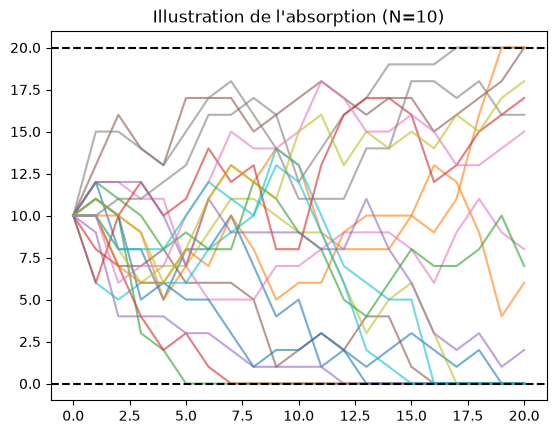

In [36]:
n = 20
N = 10
plt.figure()
for _ in range(n):
    traj = wrightfisher(N, N, n)
    plt.plot(traj, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2*N, color='black', linestyle='--')
plt.title("Illustration de l'absorption (N=10)")
plt.show()

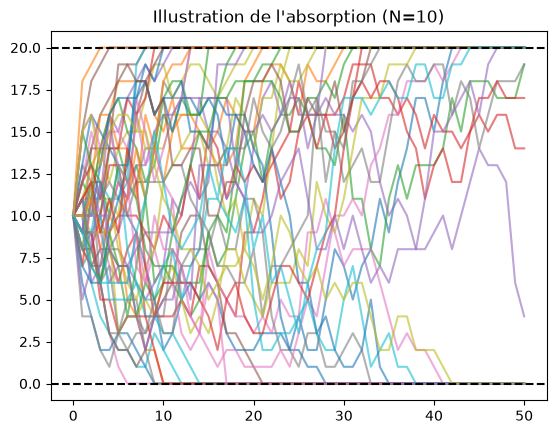

In [37]:
n = 50
N = 10
plt.figure()
for _ in range(n):
    traj = wrightfisher(N, N, n)
    plt.plot(traj, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2*N, color='black', linestyle='--')
plt.title("Illustration de l'absorption (N=10)")
plt.show()

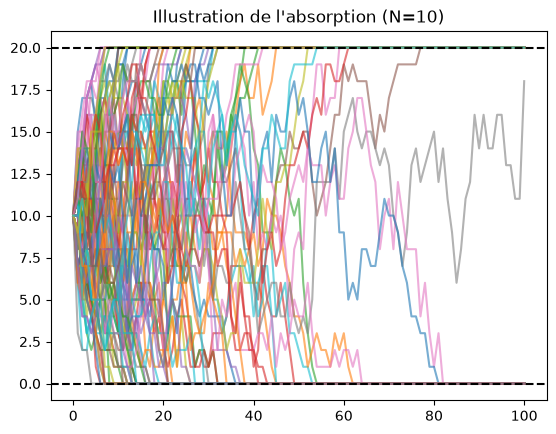

In [38]:
n = 100
N = 10
plt.figure()
for _ in range(n):
    traj = wrightfisher(N, N, n)
    plt.plot(traj, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2*N, color='black', linestyle='--')
plt.title("Illustration de l'absorption (N=10)")
plt.show()

# 3. ESTIMATION DE LA PROBABILITÉ D'EXTINCTION

Dans cette partie, on veut estimer la probabilité d'extincion de la population, c'est à dire d'absorption à zéro

On définit maintenant pour tout $i \in [0, 2N]$, $p(i) = \mathbb{P}_i \left( \bigcup_{k \in \mathbb{N}^*} (X_k = 0) \right)$ la probabilité d'absorption de la chaîne par $0$ lorsque $X_0 = i$.

Tout d'abord, si $i \in A$, alors $i = 0$ ou $i = 2N$. On a donc $p(i) = 1$ si $i = 0$, et $p(i) = 0$ si $i = 2N$.

On s'intéresse maintenant au cas où $i \notin A$. On veut proposer un estimateur $\hat{p}_m(i)$ basé sur $m$ copies indépendantes et identiquement distribuées de la chaîne $(X_k)$ partant de $i$ tel que :

$$\sqrt{m} \left( \hat{p}_m(i) - p(i) \right) \xrightarrow[m \to +\infty]{\mathcal{L}} \mathcal{N}\left(0, \sigma(i)^2\right)$$

On veut cela car ça nous permet, grâce au TCL, de construire rigoureusement des intervalles de confiance asymptotiques.

On utilisera la méthode de Monte-Carlo afin de trouver cet estimateur.

In [102]:
N = 10
n = 100
m = 100
x0 = random.randint(0,2*N)
def estimateur_p(N, n, m, x0, q=0):
    for _ in range(m):
        tab = wrightfisher(N, x0, n)
        for i in tab:
            if i == 0:
                q += 1
                break
    return q / m

Afin de pouvoir déterminer un intervalle de confiance de $\hat{p}_m(i)$, on s'intéresse à $\sigma(i)^2$. On cherche à donner un estimateur $\hat{\sigma}_m(i)^2$ tel que :

$$\hat{\sigma}_m(i)^2 \xrightarrow[m \to +\infty]{\text{p.s.}} \sigma(i)^2$$

Puisque l'on se place dans le cadre d'une répétition d'une loi de Bernoulli de paramètre $p(i)$, si $X \sim \mathcal{B}(p(i))$, alors $\text{Var}(X) = p(i)(1 - p(i))$. On définit ainsi un estimateur de $\sigma(i)^2$ par :

$$\hat{\sigma}_m(i)^2 = \hat{p}_m(i) \left(1 - \hat{p}_m(i)\right)$$

On peut alors en déduire un intervalle de confiance asymptotique de $p(i)$ au seuil de $95\%$ défini par :

$$\text{IC}_{p(i)} = \left[ \hat{p}_m(i) - z_{0.975} \frac{\hat{\sigma}_m(i)}{\sqrt{m}} \,;\,\hat{p}_m(i) + z_{0.975} \frac{\hat{\sigma}_m(i)}{\sqrt{m}} \right]$$

où $z_{0.975} \approx 1{,}96$ représente le quantile d'ordre $97{,}5\%$ de la loi normale centrée réduite.

On construit maintenant une fonction proba_zero qui nous permet de déterminer empiriquement une valeur de $\hat{p}_m(x_0)$

In [40]:
N = 10
m = 100
def proba_zero(N, x0, m):
    absorptions = 0
    for _ in range(m):
        x = x0
        if x0 == 0:
            return 1,x0
        while x > 0 and x < 2*N:
            x = binom.rvs(2*N, x / (2*N))
            if x == 0:
                absorptions += 1
    return absorptions / m, x0
for i in range(1,10):
    print(proba_zero(N,2*i,m))

(0.94, 2)
(0.78, 4)
(0.67, 6)
(0.67, 8)
(0.56, 10)
(0.38, 12)
(0.21, 14)
(0.21, 16)
(0.14, 18)


On remarque tout naturellement que le point de départ a un fort impact sur la probabilité d'absorption par 0 ou 2N. Nous allons maintenant le démonter. 

Pour $N = 10$ et $m = 1000$, nous concevons une fonction permettant de déterminer les intervalles de confiance au seuil de $95\%$ en fonction de l'état initial $i \in [0, 2N]$.

In [41]:

def p_IC(N, m):
    etats_initiaux = list(range(2 * N + 1))
    p = []
    inf = []
    sup = []
    for x0 in etats_initiaux:
        p0 = proba_zero(N, x0, m)[0]
        p += [p0]
        inf += [p0 - math.sqrt(p0*(1-p0))/math.sqrt(m) * 1.96]
        sup += [p0 + math.sqrt(p0*(1-p0))/math.sqrt(m) * 1.96]
    return (etats_initiaux, p, inf, sup, N, m)


Cette fonction nous permet d'avaoir toute les bornes sup et inf des IC en fonction de l'état initiale $x_0$. On affiche maintenant le résultat graphique :

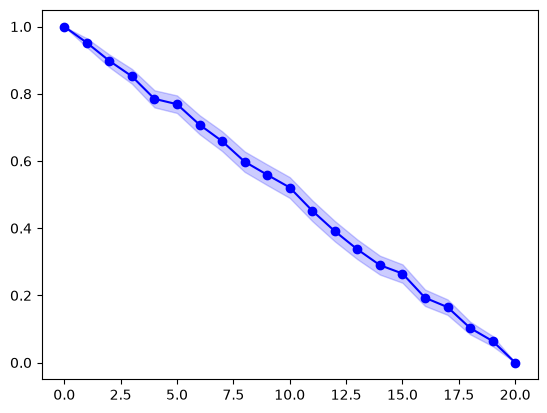

In [42]:
simule = p_IC(10, 1000)
plt.figure()
plt.plot(simule[0], simule[1], marker='o', color='b',
label=r"Estimation $\hat{p}_m(i)$")
plt.fill_between(simule[0], simule[2], simule[3], color='b',
alpha=0.2, label="Intervalle de confiance à 95%")
plt.show()

Finalement, on remarque que $p(i)$ peut être approximée par une fonction linéaire passant par les points de coordonnées $(0,1)$ et $(20,0)$, on peut donc conjecturer que $p(i)$ peut être approximée par la formule :

$$p(i) = 1 - \frac{i}{20}$$

Alors dans le cadre général avec $N$ un entier quelconque, on a :

$$p(i) = 1 - \frac{i}{2N}$$

On définit une fonction \texttt{absorption(N, x0, m)} qui renvoie une approximation de $A(x_0)$ où $x_0 \in [0, 2N]$, obtenue par une méthode de Monte-Carlo, ainsi que les bornes de l'intervalle de confiance au seuil de 95 \% associé.

# 4.TEMPS MOYEN D'ABSORPTION
Pour finir, nous allons déterminer numériquement le temps moyen d'absorption de la chaîne. Pour $i \in [0, 2N]$, on définit $A(i) = \mathbb{E}_i\left(\inf\{k \in \mathbb{N}^*, X_k \in \mathcal{A}\}\right)$ le temps moyen d'absorption de la chaîne en partant de $i$.

In [83]:
def absorption(N, x0, m):
    tab = []
    somme = 0
    for _ in range(m):
        x = x0
        t = 0
        while 0 < x < 2 * N:
            x = binom.rvs(2 * N, x / (2 * N))
            t += 1
        tab.append(t)
    return tab

On créer une fonction qui nous renvoie l'Espérance ainsi que la Variance du temps d'absorption en fonction du point de départ

In [84]:
def variance_E_emp(tab):
    m = len(tab)
    somme = 0
    somme2 = 0
    for i in tab:
        somme += i
    E = somme/m
    for i in tab:
        somme2 += (i - E)**2  
    var = somme2/(m-1)
    return E, var

On peut alors utilser la fonction variance_E_emp pour determiner notre intervalle de confiance, il sera au seuil 95% : 

In [85]:
def IC_E(N, x0, m):
    tab = absorption(N, x0, m)
    E = variance_E_emp(tab)[0]
    var = variance_E_emp(tab)[1]
    inf = E - 1.96 * math.sqrt(var / m) 
    sup = E + 1.96 * math.sqrt(var / m) 
    return E, var, inf, sup

Pour finir, on va creer un graphique qui représentera le temps moyen d'absorption en fonction du point de départ pour une population pouvant être au maximum 20 individus

In [89]:
def A_IC(N, m):
    etats_initiaux = list(range(2 * N + 1))
    A = []
    inf = []
    sup = []
    for x0 in etats_initiaux:
        if x0 == 0 or x0 == 2 * N:
            A.append(0)
            inf.append(0)
            sup.append(0)
        else:
            simulation = IC_E(N, x0, m)
            E = simulation[0]
            var = simulation[1]
            inf_val = simulation[2]
            sup_val = simulation[3]
            A.append(E)
            inf.append(inf_val)
            sup.append(sup_val)
            
    return etats_initiaux, A, inf, sup, N, m


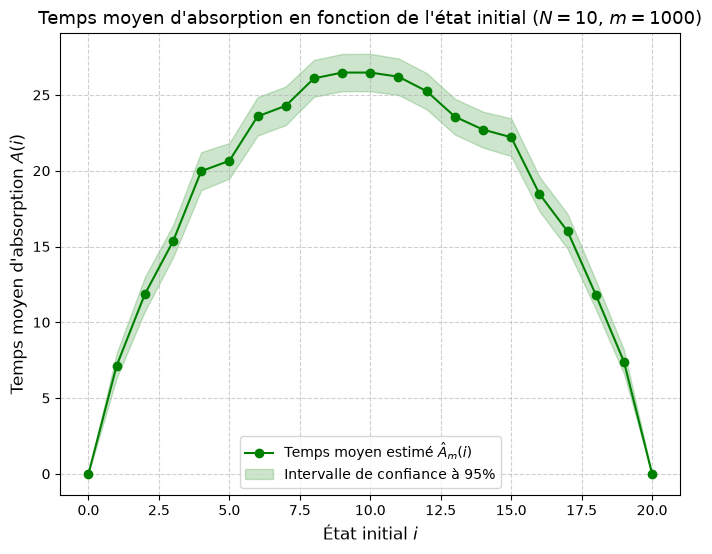

In [101]:
N = 10
m = 1000

# Génération des résultats via les fonctions
simule = A_IC(N, m)

# Tracé de la courbe et de l'intervalle de confiance
plt.figure(figsize=(8, 6))
plt.plot(simule[0], simule[1], marker='o', color='green', 
         label=r"Temps moyen estimé $\hat{A}_m(i)$")
plt.fill_between(simule[0], simule[2], simule[3], color='green', 
                 alpha=0.2, label="Intervalle de confiance à 95%")

plt.xlabel("État initial $i$", fontsize=12)
plt.ylabel("Temps moyen d'absorption $A(i)$", fontsize=12)
plt.title(f"Temps moyen d'absorption en fonction de l'état initial ($N={N}$, $m={m}$)", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower center")
plt.show()

Finalement, on observe assez naturellement que que plus le point de départ se trouve au milieux des valeurs que peux prendre la chaîne $(X_k)$, plus elle met de temps en moyenne à atteindre un de ses points absorbants